(0.0, 50.0)

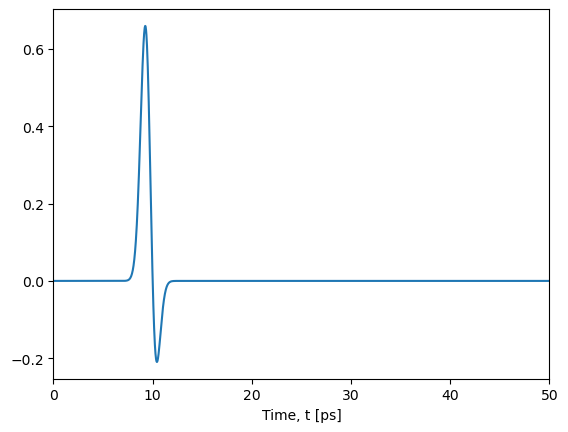

In [3]:
import numpy as np
import matplotlib.pyplot as plt 

 
def simulate_reference(L, deltat):
    toff=1.0e-11
    twidth=8e-13
    tdecay=1.0e-12
    scale=1.0e12
    x=np.zeros(L, float)
    for t in range(0,L):
        T=t*deltat - toff
        x[t]=-scale*T* np.exp(-(T/twidth)**2 - T/tdecay)

    return x

deltat=0.0194e-12
L=2**14
x=simulate_reference(L, deltat)
t_axis = np.arange(0,L*deltat, deltat)
plt.plot(t_axis*1e12, x)
plt.xlabel('Time, t [ps]')
plt.xlim(0,50)


(0.0, 3000000000000.0)

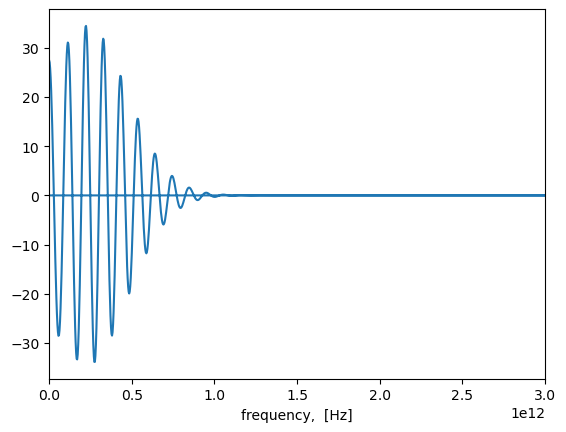

In [4]:
# FFT
fftr = np.fft.fft(x, 2**14)
freq = np.fft.fftfreq(2**14, deltat)
plt.plot(freq, np.real(fftr))
plt.xlabel('frequency,  [Hz]')
plt.xlim(0,3e12)

Define Transfer function (single reflection), Length and refractive index

(0.0, 3000000000000.0)

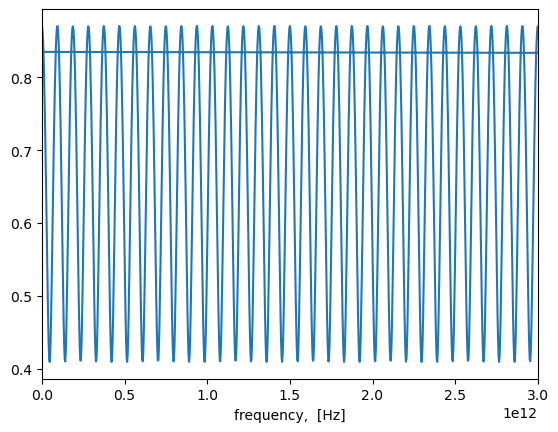

In [5]:
t=0.4e-3
c=3e8
n=4
# DEFINE FUNCTIONS
def F(n, f):
    lnH_th = (np.log((4 * n) / ((1 + n) ** 2)) 
              - 1j * t * (2 * np.pi * f) * (n - 1) / (c)
              + np.log(1 + ((n - 1) / (n + 1)) ** 2 * np.exp((-4 * 1j * n * np.pi * f * t) / c)))
    return lnH_th
Fth=np.exp(F(n,freq))
plt.plot(freq, np.abs(Fth))
plt.xlabel('frequency,  [Hz]')
plt.xlim(0,3e12)

Create sample pulse

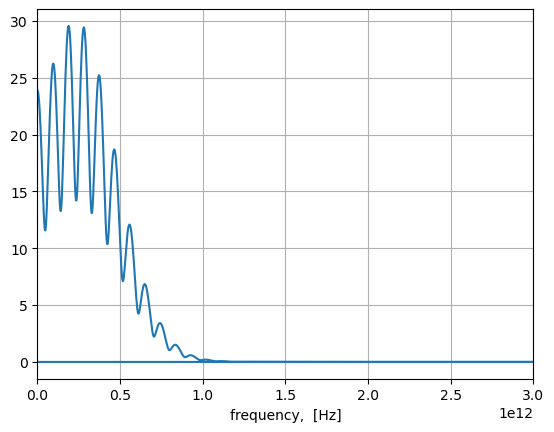

In [6]:
ffts=fftr*Fth
plt.plot(freq, np.abs(ffts))
plt.xlabel('frequency,  [Hz]')
plt.xlim(0,3e12)
plt.grid(visible=True)


dt= 3.9964e-12


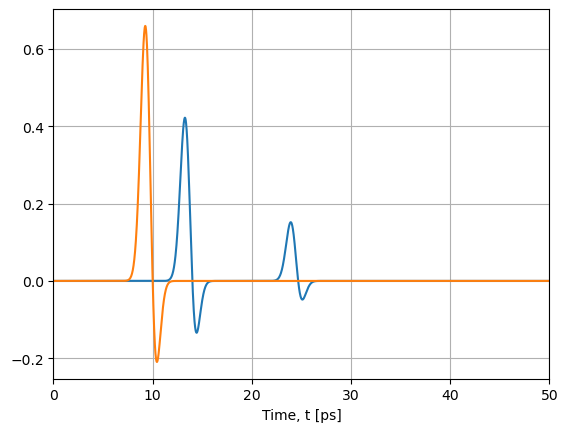

dt_theoretical= 4.000000000000001e-12


In [7]:
y=np.fft.ifft(ffts)
L=2**14
t_axis = np.arange(0,L*deltat, deltat)
plt.plot(t_axis*1e12, np.real(y),t_axis*1e12,x)
plt.xlabel('Time, t [ps]')
plt.xlim(0, 50)
plt.grid(visible=True)
max_index1 = np.argmax(np.real(y))
max_index2 = np.argmax(np.real(x))
dt=deltat*(max_index1-max_index2)
print('dt=',dt)
plt.show()
dt_theoretical = t*(n-1)/c
print('dt_theoretical=',dt_theoretical)